In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("julinmaloof/the-oxfordiiit-pet-dataset", output_dir='../data')
path = '../data'

In [19]:
from fastai.vision import *

In [14]:
import numpy as np
import pandas as pd

# Exploratory Data Analysis (EDA)

In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [12]:
fnames = os.listdir(path+'/images')
fnames[:3]

['Abyssinian_1.jpg', 'Abyssinian_10.jpg', 'Abyssinian_100.jpg']

In [15]:
np.random.seed(2) #random seed for reproducibility
pat = r'/([^/]+)_\d+.jpg$' #regex expression

In [16]:
sz = 128
bs = 64

In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [439]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.utils.data as data
import torchvision.transforms.v2 as tfs

In [31]:
import torch
import random

In [32]:
import os, sys

In [33]:
os.listdir(path+'/images')[-3:]

['yorkshire_terrier_97.jpg',
 'yorkshire_terrier_98.jpg',
 'yorkshire_terrier_99.jpg']

In [34]:
SEED = 42

In [35]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

In [37]:
os.listdir(path+'/images')[:2]

['Abyssinian_1.jpg', 'Abyssinian_10.jpg']

In [40]:
os.listdir(path+'/annotations')[:]

['.ipynb_checkpoints',
 'list.txt',
 'README',
 'test.txt',
 'trainval.txt',
 'trimaps',
 'xmls']

In [993]:
with open(Path.joinpath(Path(path), 'annotations', 'trainval.txt'), 'r') as f:
    labels = f.read()
    labels = labels.split('\n')[6:][:-1]
    labels = dict(zip([i.split()[0]+'.jpg' for i in labels], [int(i.split()[1]) for i in labels]))

In [638]:
labels['Abyssinian_10.jpg'], labels['american_bulldog_114.jpg']

(1, 2)

In [135]:
from sklearn.model_selection import train_test_split

In [186]:
from collections import Counter

In [ ]:
[1,0] 0
[0,1] 1


In [984]:
from torchvision import transforms
import torch.utils.data as data

class DigitDataset(data.Dataset):
    def __init__(self, path, train=True, transform=None):
        if train:
            annotation_file_path = Path.joinpath(Path(path), '../annotations', 'trainval.txt')
        else:
            annotation_file_path = Path.joinpath(Path(path), '../annotations', 'test.txt')
        self.path = path
        # Если transform не передан, создаем стандартный
        if transform is None:
            self.transform = transforms.Compose([
                transforms.ToTensor(),  # Преобразует PIL в тензор [0,1]
            ])
        else:
            self.transform = transform
        
        self.length = 0
        self.targets = torch.eye(37)
        # Стандартные трансформации, если не переданы
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),  # Приводим все изображения к 224x224
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.2], std=[0.5])
            ])
        else:
            self.transform = transform
        with open(annotation_file_path, 'r') as f:
            labels = f.read()
            labels = labels.split('\n')[6:][:-1]
            labels = dict(zip([self.path + '/' + i.split()[0]+'.jpg' for i in labels], [int(i.split()[1]) for i in labels]))
            
        data = labels.items()
        self.length = len(data)
        self.files = list(data)
            
    def __getitem__(self, item):
        path_file, target = self.files[item]
        img = Image.open(path_file).convert('RGB')#.convert('L' if self.transform else 'RGB')  # Для черно-белых изображений
        if self.transform:
            img = self.transform(img)
        t = self.targets[target-1]
        return img, t
 
    def __len__(self):
        return self.length

In [985]:
(Path.joinpath(Path(path), 'annotations','test.txt'))

WindowsPath('../data/annotations/test.txt')

In [1036]:
_tr = transforms.Compose([
    transforms.Resize((256, 256)),           # Сначала чуть больше
    transforms.RandomCrop(224),               # Random crop до 224x224
    transforms.RandomHorizontalFlip(p=0.5),   # Отражение по горизонтали
    transforms.RandomRotation(degrees=15),    # Поворот ±15°
    transforms.ColorJitter(
        brightness=0.2,    # Изменение яркости ±20%
        contrast=0.2,      # Контраст ±20%
        saturation=0.2,    # Насыщенность ±20%
        hue=0.1            # Оттенок ±10%
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),  # Сдвиг до 10%
        scale=(0.9, 1.1)        # Масштаб 90%-110%
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [1037]:
d_train = DigitDataset('../data/images', transform=_tr)
d_test = DigitDataset('../data/images', train=False, transform=_tr)
train_data = data.DataLoader(d_train, batch_size=100, shuffle=True)
test_data = data.DataLoader(d_train, batch_size=100, shuffle=True)
img = Image.open('../data/images/Birman_88.jpg').convert('L' if None else 'RGB')  # Для черно-белых изображений

In [1021]:
it = iter(train_data)

In [1022]:
a = next(it)

In [1023]:
torch.argmax(a[1][0]).item()

11

In [994]:
names = dict(zip([' '.join(i.split('_')[:-1]) for i in labels], [i for i in labels.values()]))
names = dict(zip(names.values(), names.keys()))
names 

{1: 'Abyssinian',
 2: 'american bulldog',
 3: 'american pit bull terrier',
 4: 'basset hound',
 5: 'beagle',
 6: 'Bengal',
 7: 'Birman',
 8: 'Bombay',
 9: 'boxer',
 10: 'British Shorthair',
 11: 'chihuahua',
 12: 'Egyptian Mau',
 13: 'english cocker spaniel',
 14: 'english setter',
 15: 'german shorthaired',
 16: 'great pyrenees',
 17: 'havanese',
 18: 'japanese chin',
 19: 'keeshond',
 20: 'leonberger',
 21: 'Maine Coon',
 22: 'miniature pinscher',
 23: 'newfoundland',
 24: 'Persian',
 25: 'pomeranian',
 26: 'pug',
 27: 'Ragdoll',
 28: 'Russian Blue',
 29: 'saint bernard',
 30: 'samoyed',
 31: 'scottish terrier',
 32: 'shiba inu',
 33: 'Siamese',
 34: 'Sphynx',
 35: 'staffordshire bull terrier',
 36: 'wheaten terrier',
 37: 'yorkshire terrier'}

In [995]:
names[int(np.argmax(a[1][0])+1)]

'great pyrenees'

In [996]:
int(np.argmax(a[1][2]))

29

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8207895].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6291069].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5005665].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5810429].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3611329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.46

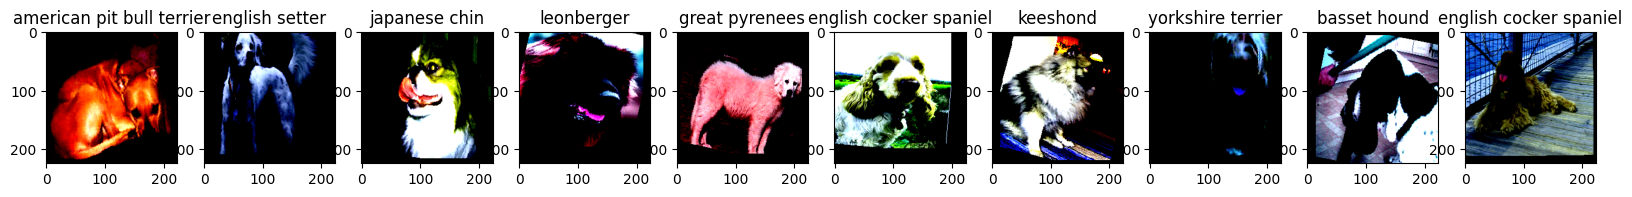

In [1038]:
a = next(it)
n=10
fig, ax = plt.subplots(ncols=n)
fig.set_size_inches(20,7)
for i in range(n):
    ax[i].imshow(np.transpose(a[0][i], (1,2,0)))
    ax[i].set_title(names[int(np.argmax(a[1][i]))+1])
plt.show()

# 1. EDA
## 1.1. Распределение классов

In [998]:
len(d_train.files)

3674

In [999]:
len(d_test.files)

3663

### Разница в выборках TRN/TST

In [1000]:
Counter([j for i,j in d_test.files]) - Counter([j for i,j in d_train.files])

Counter({12: 4, 13: 4, 23: 4, 33: 1})

In [1001]:
Counter([j for i,j in d_train.files])

Counter({2: 100,
         3: 100,
         4: 100,
         5: 100,
         6: 100,
         7: 100,
         9: 100,
         10: 100,
         11: 100,
         14: 100,
         15: 100,
         16: 100,
         17: 100,
         18: 100,
         19: 100,
         20: 100,
         21: 100,
         22: 100,
         24: 100,
         25: 100,
         26: 100,
         27: 100,
         28: 100,
         29: 100,
         30: 100,
         31: 100,
         32: 100,
         34: 100,
         35: 100,
         36: 100,
         37: 100,
         33: 99,
         8: 96,
         13: 96,
         23: 96,
         1: 94,
         12: 93})

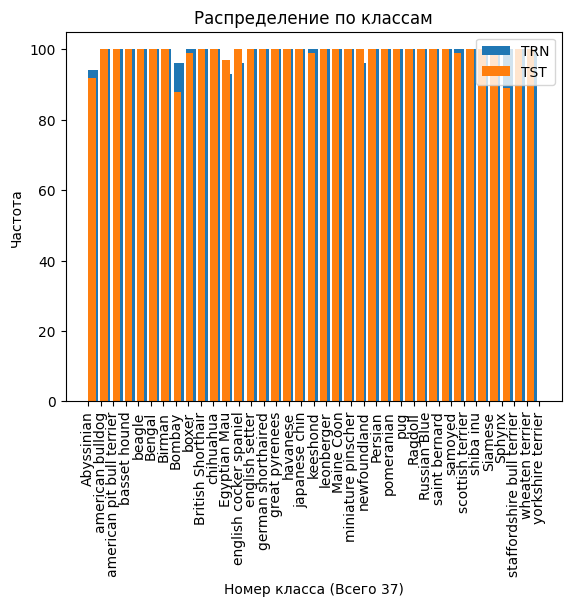

In [1002]:
plt.hist([_ for _ in list(map(lambda x: names[x], [j for i,j in d_train.files]))], bins=37, width=0.8)
plt.hist([_ for _ in list(map(lambda x: names[x], [j for i,j in d_test.files]))], bins=37, width=0.6)
plt.title('Распределение по классам')
plt.xlabel('Номер класса (Всего 37)')
plt.xticks(rotation=90)
plt.ylabel('Частота')
plt.legend(['TRN','TST']);

In [1003]:
tr = transforms.Compose([
                transforms.ToTensor(),  # Преобразует PIL в тензор [0,1]
                transforms.Normalize(mean=[0.5], std=[0.5])  # Опционально: нормализация
            ])

# 2. Обучение

## 2.1. Baseline model

In [1006]:
from torchvision.transforms import v2

In [1039]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import time


# ==================== МОДЕЛЬ ====================

class Net(nn.Module):
    def __init__(self, num_classes=37):
        super().__init__()
        # Блок 1: 224x224 -> 112x112 -> 56x56
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)  # 224 -> 112
        
        # Блок 2: 112x112 -> 56x56 -> 28x28
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)  # 112 -> 56
        
        # Блок 3: 56x56 -> 28x28 -> 14x14
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)  # 56 -> 28
        
        # Блок 4: 28x28 -> 14x14 -> 7x7
        self.conv7 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(512)
        self.conv8 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(512)
        self.pool4 = nn.MaxPool2d(2, 2)  # 28 -> 14
        
        # Блок 5: 14x14 -> 7x7
        self.conv9 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn9 = nn.BatchNorm2d(512)
        self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn10 = nn.BatchNorm2d(512)
        self.pool5 = nn.MaxPool2d(2, 2)  # 14 -> 7
        
        # Классификатор
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(512, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Блок 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        
        # Блок 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        
        # Блок 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)
        
        # Блок 4
        x = F.relu(self.bn7(self.conv7(x)))
        x = F.relu(self.bn8(self.conv8(x)))
        x = self.pool4(x)
        
        # Блок 5
        x = F.relu(self.bn9(self.conv9(x)))
        x = F.relu(self.bn10(self.conv10(x)))
        x = self.pool5(x)
        
        # Классификатор
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# ==================== TRAIN LOOP ====================

def train_model(
    model,
    train_loader,
    val_loader=None,
    num_epochs=25,
    lr=0.001,
    weight_decay=1e-4,
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    print(f"Training on {device}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        # ===== TRAIN =====
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            if labels.dim() > 1:
                labels = labels.argmax(dim=1)  # one-hot -> индексы
                labels = labels.long()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            if batch_idx % 10 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
        
        epoch_loss = running_loss / total
        epoch_acc = 100. * correct / total
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        
        # ===== VALIDATION =====
        val_loss, val_acc = 0.0, 0.0
        if val_loader is not None:
            model.eval()
            val_running_loss = 0.0
            val_correct = 0
            val_total = 0
            
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    if labels.dim() > 1:
                        labels = labels.argmax(dim=1)  # one-hot -> индексы
                    labels = labels.long()
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    
                    val_running_loss += loss.item() * images.size(0)
                    _, predicted = outputs.max(1)
                    val_total += labels.size(0)
                    val_correct += predicted.eq(labels).sum().item()
            
            val_loss = val_running_loss / val_total
            val_acc = 100. * val_correct / val_total
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            
            # Сохранение лучшей модели
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': val_acc,
                }, 'best_model.pth')
                print(f"  ✓ Saved best model (val_acc: {val_acc:.2f}%)")
        
        scheduler.step()
        elapsed = time.time() - start_time
        
        print(f"\nEpoch [{epoch+1}/{num_epochs}] | Time: {elapsed:.1f}s")
        print(f"  Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%")
        if val_loader:
            print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print("-" * 50)
    
    print(f"\nBest validation accuracy: {best_val_acc:.2f}%")
    return history


def evaluate_model(model, test_loader, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model = model.to(device)
    model.eval()
    
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = 100. * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc, all_preds, all_labels


# ==================== ПРИМЕР ИСПОЛЬЗОВАНИЯ ====================

if __name__ == "__main__":
    # Трансформации
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Создание модели
    model = Net(num_classes=37)
    
    # Проверка размеров
    test_input = torch.randn(2, 3, 224, 224)
    test_output = model(test_input)
    print(f"Input shape:  {test_input.shape}")
    print(f"Output shape: {test_output.shape}")  # [2, 37]
    
    # Для запуска обучения раскомментируй:
    """
    from torchvision.datasets import ImageFolder
    
    train_dataset = ImageFolder('path/to/train', transform=train_transform)
    val_dataset = ImageFolder('path/to/val', transform=val_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
    
    history = train_model(model, train_loader, val_loader, num_epochs=30)
    """

Input shape:  torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 37])


In [ ]:
%%time
history = train_model(model, train_data, test_data, num_epochs=30)

In [1049]:
1

1

In [1046]:
history.keys()

dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])

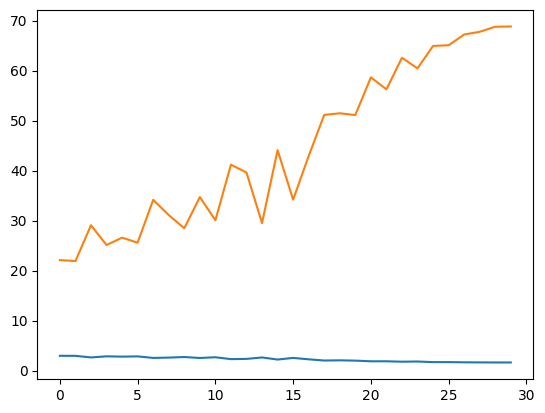

In [1047]:
plt.plot(history['val_loss'])
plt.plot(history['val_acc'])

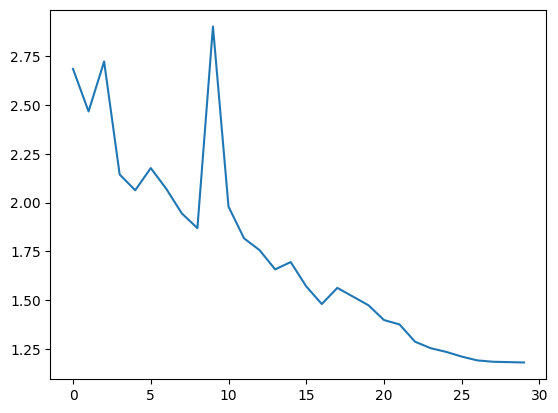

In [1053]:
plt.plot(history['val_loss'])
# plt.plot(history['val_acc'])

In [1055]:
torch.save(model.state_dict(), '../data/model_weights.pth')

In [1075]:
len(test_data)

37

In [1080]:
it = iter(test_data)

In [1101]:
images, labels = next(it)

In [1102]:
outputs = model(images.to(device))

In [1105]:
(outputs.argmax(axis=1)) - labels.to(device).argmax(axis=1)

tensor([  0,   0, -26,   0,   8,   0,   0,   0,  20,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   0,   0,   0,
          0,   0,   0,   0,   0,   1,   0,   0,   0,   0,   0,   0,   0,  -6,
          0, -18,   0,   0,   0,   0,   0,   0,   0,   0,  14,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,  -1,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   0,   0,   0,   0,
          0,   0], device='cuda:0')

In [1108]:
outputs.max(1)

torch.return_types.max(
values=tensor([4.9326, 3.8043, 3.0554, 3.4257, 1.6477, 5.3610, 4.7328, 5.3156, 1.2374,
        3.5595, 4.0966, 4.7016, 5.2144, 5.4149, 3.1193, 3.2072, 2.7038, 3.1481,
        4.9389, 2.9944, 5.2137, 3.9830, 3.3162, 5.6897, 1.6059, 2.5268, 4.7913,
        5.2802, 2.8622, 2.1731, 4.1838, 3.0455, 5.5914, 3.8387, 3.1470, 5.1305,
        1.6550, 4.0035, 3.6467, 3.7248, 3.1142, 2.8077, 6.2188, 2.8405, 6.0788,
        2.6780, 4.3929, 5.6060, 1.3445, 2.2321, 3.5452, 3.7271, 3.8604, 3.4579,
        3.8424, 3.0118, 1.4686, 5.5469, 3.4014, 3.5984, 6.0646, 3.5834, 2.6061,
        2.2242, 1.5936, 4.7001, 3.0378, 3.8357, 1.4273, 2.7977, 3.6897, 2.6895,
        4.0956, 1.9905, 5.3023, 6.1203, 4.0299, 3.7665, 3.8948, 4.0844, 1.8010,
        2.4679, 2.6890, 3.2365, 1.4910, 2.6601, 3.0605, 5.4111, 0.6791, 6.9311,
        3.8995, 5.4317, 2.4404, 0.2762, 3.3137, 2.6776, 5.8284, 3.7038, 1.3576,
        2.8360], device='cuda:0', grad_fn=<MaxBackward0>),
indices=tensor([28, 14,  8,  0

In [1110]:
labels.argmax(1)

tensor([28, 14, 34,  0,  2, 11, 28,  1,  6, 13, 23, 15, 34, 28,  4, 20, 25,  0,
        26, 18, 25, 33,  4, 16, 19, 15, 32, 25, 18, 17, 34,  3, 15,  1,  3, 17,
        15,  9, 11, 27,  5, 11, 25, 27, 29, 33, 29, 29, 27, 27,  0,  1, 15, 32,
        27,  8, 22, 25, 18, 26,  8, 27, 14, 35, 35, 31, 36, 18,  3, 22,  5, 10,
        23, 26, 28, 25,  4, 34,  2, 28, 15,  8, 20, 20,  4, 28, 34, 32,  4, 29,
        25, 19, 31,  6, 24,  0,  4, 19,  0, 14])

In [1111]:
labels.size(0)

100

In [1118]:
acc, all_preds, all_labels = evaluate_model(model, test_data)

Test Accuracy: 87.40%


## 2.2. Transfer learning
### 2.2.1. Alexnet

In [1120]:
import torchvision

In [1127]:
def create_alexnet(num_classes=10, freeze_features=True):
    """
    freeze_features=True  -> замораживаем свёрточные слои, учим только классификатор
    freeze_features=False -> fine-tuning всей модели
    """
    model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
    
    # Замораживаем feature extractor (если нужно)
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False
    
    # Заменяем классификатор на свой (AlexNet: 4096 -> 4096 -> 1000)
    # Новый классификатор с Dropout
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(256 * 6 * 6, 4096),  # AlexNet feature output: 256x6x6=9216
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.5),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Linear(4096, num_classes)     # <-- 10 классов вместо 1000
    )
    
    return model

In [1131]:
# Создаём модель
model = create_alexnet(num_classes=37, freeze_features=True)
model = model.to(device)

print(f"Параметров всего: {sum(p.numel() for p in model.parameters()):,}")
print(f"Обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ============ 4. ОБУЧЕНИЕ ============

def train_alexnet(model, train_loader, val_loader, num_epochs=30, lr=0.001, device='cuda'):
    # Разные lr для feature extractor и classifier (если fine-tuning)
    # При freeze_features=True оптимизируем только classifier
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # Оптимизатор: только обучаемые параметры
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )
    
    # Scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        # ===== TRAIN =====
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels.argmax(1)).sum().item()
            
            if batch_idx % 20 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
        
        train_loss = running_loss / total
        train_acc = 100. * correct / total
        
        # ===== VALIDATION =====
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels.argmax(1)).sum().item()
        
        val_loss /= val_total
        val_acc = 100. * val_correct / val_total
        
        # Сохранение лучшей модели
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, 'best_alexnet.pth')
            print(f"  ✓ Сохранена лучшая модель (val_acc: {val_acc:.2f}%)")
        
        scheduler.step()
        elapsed = time.time() - start_time
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"\nEpoch [{epoch+1}/{num_epochs}] | {elapsed:.1f}s")
        print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"  Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
        print("-" * 50)
    
    print(f"\nЛучшая val accuracy: {best_val_acc:.2f}%")
    return history

Параметров всего: 57,155,429
Обучаемых параметров: 54,685,733


In [1132]:
history = train_alexnet(
    model, 
    train_data, 
    test_data, 
    num_epochs=25,
    lr=0.001,
    device=device
)

  Batch 0/37, Loss: 3.7094
  Batch 20/37, Loss: 3.2752
  ✓ Сохранена лучшая модель (val_acc: 47.31%)

Epoch [1/25] | 105.8s
  Train: Loss=4.2469, Acc=14.89%
  Val:   Loss=2.2957, Acc=47.31%
--------------------------------------------------
  Batch 0/37, Loss: 2.6534
  Batch 20/37, Loss: 2.6522
  ✓ Сохранена лучшая модель (val_acc: 53.08%)

Epoch [2/25] | 116.7s
  Train: Loss=2.5071, Acc=36.31%
  Val:   Loss=2.0224, Acc=53.08%
--------------------------------------------------
  Batch 0/37, Loss: 2.5207
  Batch 20/37, Loss: 2.4440
  ✓ Сохранена лучшая модель (val_acc: 61.89%)

Epoch [3/25] | 116.3s
  Train: Loss=2.3351, Acc=42.16%
  Val:   Loss=1.8535, Acc=61.89%
--------------------------------------------------
  Batch 0/37, Loss: 2.1468
  Batch 20/37, Loss: 2.1849
  ✓ Сохранена лучшая модель (val_acc: 64.21%)

Epoch [4/25] | 116.3s
  Train: Loss=2.2170, Acc=44.37%
  Val:   Loss=1.8013, Acc=64.21%
--------------------------------------------------
  Batch 0/37, Loss: 2.1583
  Batch 2

дообучаем

In [1136]:
history = train_alexnet(
    model, 
    train_data, 
    test_data, 
    num_epochs=20,
    lr=0.0003,
    device=device
)

  Batch 0/37, Loss: 1.5037
  Batch 20/37, Loss: 1.5963
  ✓ Сохранена лучшая модель (val_acc: 87.04%)

Epoch [1/20] | 120.8s
  Train: Loss=1.4961, Acc=72.05%
  Val:   Loss=1.3076, Acc=87.04%
--------------------------------------------------
  Batch 0/37, Loss: 1.5438
  Batch 20/37, Loss: 1.3385

Epoch [2/20] | 109.6s
  Train: Loss=1.4710, Acc=72.70%
  Val:   Loss=1.3086, Acc=86.39%
--------------------------------------------------
  Batch 0/37, Loss: 1.3397
  Batch 20/37, Loss: 1.4609
  ✓ Сохранена лучшая модель (val_acc: 87.56%)

Epoch [3/20] | 113.2s
  Train: Loss=1.4867, Acc=72.40%
  Val:   Loss=1.3224, Acc=87.56%
--------------------------------------------------
  Batch 0/37, Loss: 1.5675
  Batch 20/37, Loss: 1.3708

Epoch [4/20] | 110.5s
  Train: Loss=1.4533, Acc=73.92%
  Val:   Loss=1.3257, Acc=86.99%
--------------------------------------------------
  Batch 0/37, Loss: 1.4389
  Batch 20/37, Loss: 1.4948

Epoch [5/20] | 110.1s
  Train: Loss=1.4570, Acc=73.30%
  Val:   Loss=1.3

In [1137]:
acc, all_preds, all_labels = evaluate_model(model, test_data)

Test Accuracy: 89.52%


### 2.2.2. VGG

In [1145]:
def create_vgg(num_classes=10, freeze_features=True):
    """
    freeze_features=True  -> замораживаем свёрточные слои, учим только классификатор
    freeze_features=False -> fine-tuning всей модели
    """
    model = models.vgg11(weights=models.VGG11_Weights.IMAGENET1K_V1)
    
    # Замораживаем feature extractor (если нужно)
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False
    
    # Заменяем классификатор на свой (AlexNet: 4096 -> 4096 -> 1000)
    # Новый классификатор с Dropout
    model.classifier = nn.Sequential(
        nn.Linear(in_features=25088, out_features=4096, bias=True),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.5),
        nn.Linear(in_features=4096, out_features=4096, bias=True),
        nn.ReLU(inplace=True),
        nn.Linear(4096, num_classes, bias=True)     # <-- 10 классов вместо 1000
    )
    
    return model

In [1146]:
# Создаём модель
model = create_vgg(num_classes=37, freeze_features=True)
model = model.to(device)

print(f"Параметров всего: {sum(p.numel() for p in model.parameters()):,}")
print(f"Обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ============ 4. ОБУЧЕНИЕ ============

def train_alexnet(model, train_loader, val_loader, num_epochs=30, lr=0.001, device='cuda'):
    # Разные lr для feature extractor и classifier (если fine-tuning)
    # При freeze_features=True оптимизируем только classifier
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # Оптимизатор: только обучаемые параметры
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )
    
    # Scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        # ===== TRAIN =====
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels.argmax(1)).sum().item()
            
            if batch_idx % 20 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
        
        train_loss = running_loss / total
        train_acc = 100. * correct / total
        
        # ===== VALIDATION =====
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels.argmax(1)).sum().item()
        
        val_loss /= val_total
        val_acc = 100. * val_correct / val_total
        
        # Сохранение лучшей модели
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
            }, 'best_alexnet.pth')
            print(f"  ✓ Сохранена лучшая модель (val_acc: {val_acc:.2f}%)")
        
        scheduler.step()
        elapsed = time.time() - start_time
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"\nEpoch [{epoch+1}/{num_epochs}] | {elapsed:.1f}s")
        print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"  Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
        print("-" * 50)
    
    print(f"\nЛучшая val accuracy: {best_val_acc:.2f}%")
    return history

Параметров всего: 128,917,925
Обучаемых параметров: 119,697,445


Параметров слишком много, полностью на GPU не помещаются. Пробую меньшие батчи

In [1159]:
d_train = DigitDataset('../data/images', transform=_tr)
d_test = DigitDataset('../data/images', train=False, transform=_tr)
train_data = data.DataLoader(d_train, batch_size=40, shuffle=True)
test_data = data.DataLoader(d_train, batch_size=40, shuffle=True)
img = Image.open('../data/images/Birman_88.jpg').convert('L' if None else 'RGB')  # Для черно-белых изображений

In [1161]:
%%time
history = train_alexnet(
    model, 
    train_data, 
    test_data, 
    num_epochs=25,
    lr=0.001,
    device=device
)

  Batch 0/92, Loss: 1.9402
  Batch 20/92, Loss: 2.7605
  Batch 40/92, Loss: 2.2125
  Batch 60/92, Loss: 2.5470
  Batch 80/92, Loss: 2.1865
  ✓ Сохранена лучшая модель (val_acc: 69.27%)

Epoch [1/25] | 389.8s
  Train: Loss=2.2457, Acc=44.61%
  Val:   Loss=1.7797, Acc=69.27%
--------------------------------------------------
  Batch 0/92, Loss: 1.8558
  Batch 20/92, Loss: 1.7838
  Batch 40/92, Loss: 2.0426
  Batch 60/92, Loss: 2.0008
  Batch 80/92, Loss: 1.9131
  ✓ Сохранена лучшая модель (val_acc: 71.39%)

Epoch [2/25] | 389.2s
  Train: Loss=2.0603, Acc=52.45%
  Val:   Loss=1.6439, Acc=71.39%
--------------------------------------------------
  Batch 0/92, Loss: 2.1125
  Batch 20/92, Loss: 1.8235
  Batch 40/92, Loss: 1.8854
  Batch 60/92, Loss: 2.2175
  Batch 80/92, Loss: 1.8556
  ✓ Сохранена лучшая модель (val_acc: 73.73%)

Epoch [3/25] | 391.5s
  Train: Loss=1.9443, Acc=57.57%
  Val:   Loss=1.6078, Acc=73.73%
--------------------------------------------------
  Batch 0/92, Loss: 1.745

KeyboardInterrupt: 

дообучаем

In [1162]:
acc, all_preds, all_labels = evaluate_model(model, test_data)

Test Accuracy: 90.36%
